In [1]:
import os
os.chdir('../../../..')
print(os.getcwd())
from Simulation.libraries.SimulationLib.Environment import *
import matplotlib.pyplot as plt
import numpy as np

/Users/titonka/FAIRIS


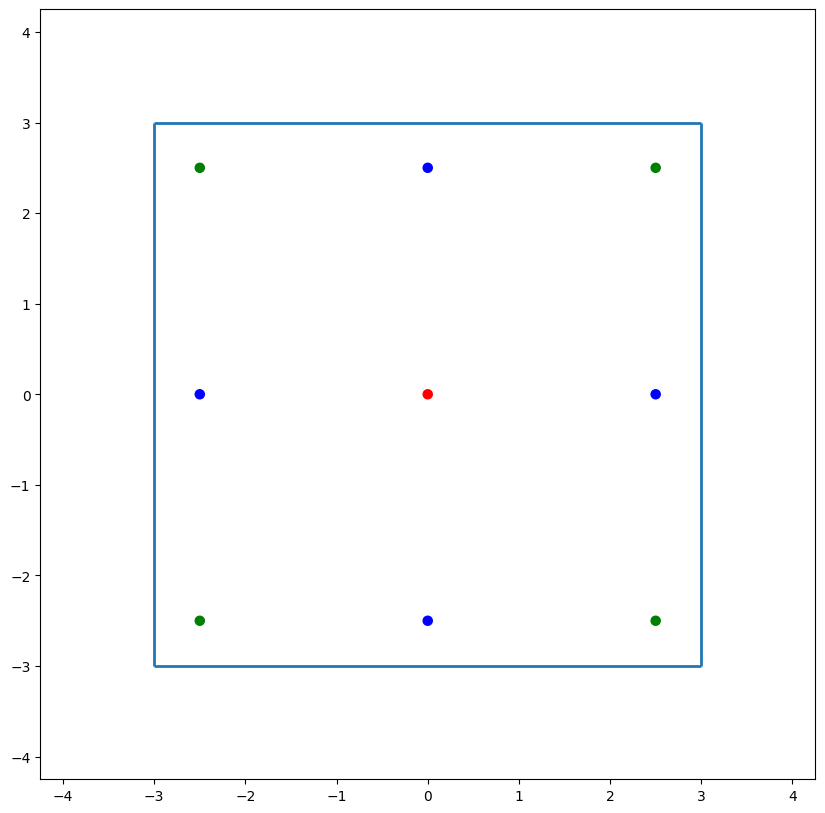

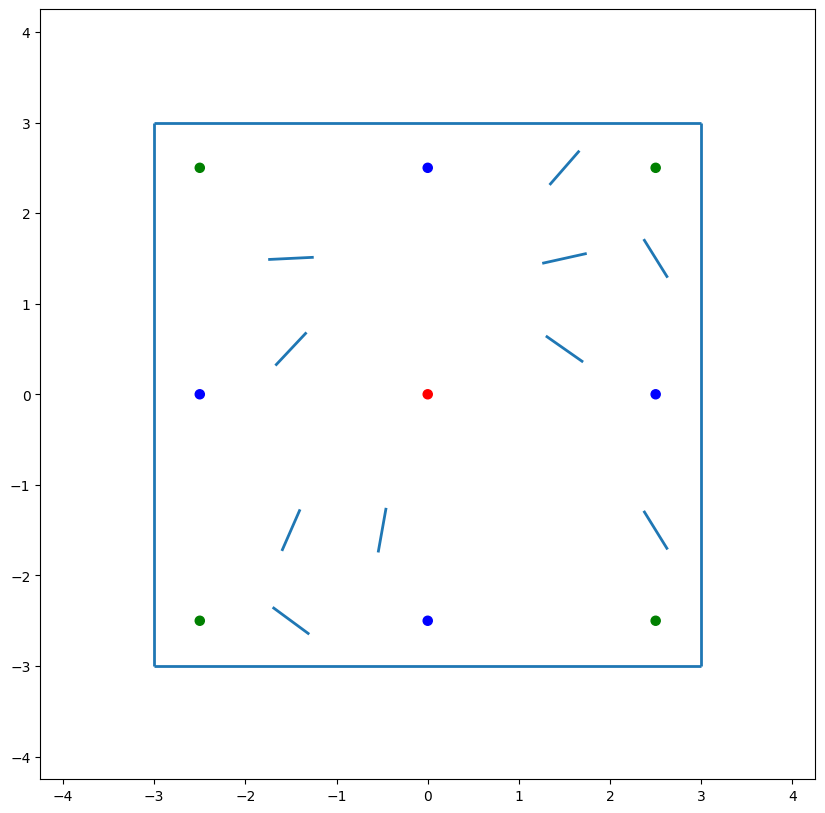

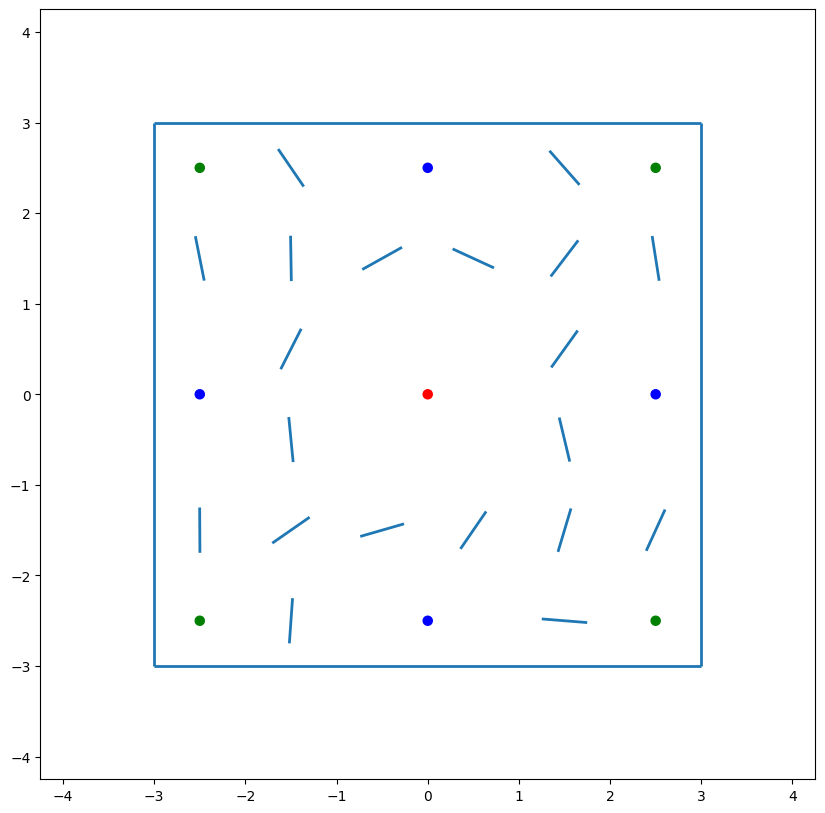

In [2]:
import csv
from ExperimentTools.utils.ExperimentLogger import EpisodeLogger, ExperimentLogger, ShortestPath
import pickle
import math

maze_files = ['WM00_paths.pkl','WM10_paths.pkl','WM20_paths.pkl']
mazes = []
for maze_file in maze_files:
    with open('Simulation/worlds/mazes/Experiment1/Paths/'+maze_file,'rb') as file:
        mazes.append(pickle.load(file))

def load_episodes_from_csv(filename):
    episodes = []
    with open(filename, 'r') as file:
        reader = csv.reader(file)
        current_episode = []
        
        for row in reader:
            if not row:  # Blank line signifies a new episode
                if current_episode:
                    episodes.append(current_episode)
                    current_episode = []
                continue
            
            # Convert row to a tuple of floats and add to the current episode
            current_episode.append(list(map(float, row)))
        
        if current_episode:  # Add the last episode if it exists
            episodes.append(current_episode)

    return episodes

def log_optimality_ratio(exp_data):
    maze_names = ['WM00','WM10','WM20']
    path_data = []
    name_index = 0
    for maze in mazes:
        starting_points = []
        path_lengths = []
        for path in maze.paths:
            starting_points.append(path.path[0])
            path_lengths.append(len(path.path)-1)
        path_data.append(ShortestPath(maze_names[name_index],starting_points,path_lengths))
        name_index += 1
    
    path_metrics = {
        'WM00': path_data[0],
        'WM10': path_data[1],
        'WM20': path_data[2]
    }
    for experiment in exp_data:
        maze_ver = experiment.maze_file
        if maze_ver == 'WM00':
            data_index = 0
        elif maze_ver == 'WM10':
            data_index = 1
        shortest_path = path_metrics.get(maze_ver)
        for episode in experiment.episodes:
            start = (episode.path_xs[0] , episode.path_ys[0])
            min_dist = 100
            for s in shortest_path.starting_points:
                dist = math.sqrt((start[0] - s[0])**2 + (start[1]-s[1])**2)
                if dist < min_dist:
                    min_dist = dist
                    eps_start = s  
            min_length = int(shortest_path.path_lengths.get(eps_start))        
            optimality_ratio = (episode.path_length - min_length)/min_length
            experiment.log_optimality_ratio_of_paths(optimality_ratio)

experiment_data_WM00 = []
experiment_data_WM10 = []
        
for i in range(10):
    data_WM00 = load_episodes_from_csv('ExperimentTools/ExperimentFigures/FigureGeneration/MSRLData/PPO_comparison_WM00_V'+str(i)+'.csv')
    data_WM10 = load_episodes_from_csv('ExperimentTools/ExperimentFigures/FigureGeneration/MSRLData/PPO_comparison_WM10_V'+str(i)+'.csv')
    
    temp_logger_WM00 = ExperimentLogger('WM00','uniform_25')
    temp_logger_WM00.log_from_csv(data_WM00)
    temp_logger_WM10 = ExperimentLogger('WM10','uniform_25')
    temp_logger_WM10.log_from_csv(data_WM00)
    
    experiment_data_WM00.append(temp_logger_WM00)
    experiment_data_WM10.append(temp_logger_WM10)

with open('logs/LargeScale/All_MSRL_WM00_uniform_25_WM','wb') as file:
    pickle.dump(experiment_data_WM00,file)

with open('logs/LargeScale/All_MSRL_WM10_uniform_25_WM','wb') as file:
    pickle.dump(experiment_data_WM10,file)

# data_WM00 = load_episodes_from_csv('ExperimentTools/ExperimentFigures/FigureGeneration/MSRLData/WM00_PPO_comparison.csv')
# data_WM10 = load_episodes_from_csv('ExperimentTools/ExperimentFigures/FigureGeneration/MSRLData/WM10_PPO_comparison.csv')
# WM00 = ExperimentLogger('WM00','uniform_25')
# WM00.log_from_csv(data_WM00)
# WM10 = ExperimentLogger('WM10','uniform_25')
# WM10.log_from_csv(data_WM10)
# exp_data_MC = [WM00,WM10] 
# log_optimality_ratio(exp_data_MC)
# 
# with open('logs/AllPPOTrainData_uniform_25_MW00V3','rb') as file:
#     experiment_data1 = pickle.load(file)
#     experiment_data1 = ExperimentLogger(old_data=experiment_data1[0])
# with open('logs/AllPPOTrainData_uniform_25_MW10V3','rb') as file:
#     experiment_data2 = pickle.load(file)    
#     experiment_data2 = ExperimentLogger(old_data=experiment_data2[0])
# exp_data = [experiment_data1,experiment_data2]
# log_optimality_ratio(exp_data)
# 
# with open('logs/AllPPOTrainData_uniform_25_MW00_no_mem','rb') as file:
#     experiment_data3 = pickle.load(file)
#     experiment_data3 = ExperimentLogger(old_data=experiment_data3[0])
# with open('logs/AllPPOTrainData_uniform_25_MW10_no_mem','rb') as file:
#     experiment_data4 = pickle.load(file)    
#     experiment_data4 = ExperimentLogger(old_data=experiment_data4[0])
# exp_data_no_mem = [experiment_data3,experiment_data4]
# log_optimality_ratio(exp_data_no_mem)
# 
# with open('logs/AllPPOTrainData_no_pc','rb') as file:
#     experiment_data5 = pickle.load(file)
#     experiment_data5 = ExperimentLogger(old_data=experiment_data5[0])
# with open('logs/AllPPOTrainData_no_pc','rb') as file:
#     experiment_data6 = pickle.load(file)    
#     experiment_data6 = ExperimentLogger(old_data=experiment_data6[0])
# exp_data_no_pc = [experiment_data5,experiment_data6]
# log_optimality_ratio(exp_data_no_pc)


In [8]:
maze_names = ['WM00','WM10','WM20']
path_data = []
name_index = 0
for maze in mazes:
    starting_points = []
    path_lengths = []
    for path in maze.paths:
        starting_points.append(path.path[0])
        path_lengths.append(len(path.path)-1)
    path_data.append(ShortestPath(maze_names[name_index],starting_points,path_lengths))
    name_index += 1

path_metrics = {
    'WM00': path_data[0],
    'WM10': path_data[1],
    'WM20': path_data[2]
}

In [9]:
data1 = np.array(exp_data_MC[0].optimality_ratio_history[0:2000])
episode = 0
learning_time = 0
freq = 0
for d in data1:
    if d <=0.5:
        learning_time = episode
        freq +=1
        if freq >25:
            break
    episode += 1
print(learning_time)

333


In [12]:
def plot_last_paths(experiment_data):
    maze_figure, maze_figure_ax = plt.subplots(1, 2, figsize=(12, 6))
    maze = Maze('Simulation/worlds/mazes/Experiment1/'+experiment_data[0].maze_file+'.xml')
    maze2 = Maze('Simulation/worlds/mazes/Experiment1/'+experiment_data[1].maze_file+'.xml')
    maze_figure_ax[0].add_collection(pycol.LineCollection(maze.walls, linewidths=2))
    maze_figure_ax[1].add_collection(pycol.LineCollection(maze2.walls, linewidths=2))
    # maze_figure_ax[2].add_collection(pycol.LineCollection(maze.walls, linewidths=2))
    
    for point in maze.experiment_starting_location:
        new_crc = patches.Circle((point.x, point.y), radius=.05, color='green')
        new_crc1 = patches.Circle((point.x, point.y), radius=.05, color='green')
        # new_crc2 = patches.Circle((point.x, point.y), radius=.05, color='green')
        maze_figure_ax[0].add_patch(new_crc)
        maze_figure_ax[1].add_patch(new_crc1)
        # maze_figure_ax[2].add_patch(new_crc2)
    for point in maze.habituation_start_location:
        new_crc = patches.Circle((point.x, point.y), radius=.05, color='blue')
        new_crc1 = patches.Circle((point.x, point.y), radius=.05, color='blue')
        # new_crc2 = patches.Circle((point.x, point.y), radius=.05, color='blue')
        maze_figure_ax[0].add_patch(new_crc)
        maze_figure_ax[1].add_patch(new_crc1)
        # maze_figure_ax[2].add_patch(new_crc2)
    for point in maze.goal_locations:
        new_crc = patches.Circle((point.x, point.y), radius=.05, color='red')
        new_crc1 = patches.Circle((point.x, point.y), radius=.05, color='red')
        # new_crc2 = patches.Circle((point.x, point.y), radius=.05, color='red')
        maze_figure_ax[0].add_patch(new_crc)
        maze_figure_ax[1].add_patch(new_crc1)
        # maze_figure_ax[2].add_patch(new_crc2)

    for i in range(len(experiment_data)):
        maze_figure_ax[i].plot(experiment_data[i].episodes[-1].path_xs,experiment_data[i].episodes[-1].path_ys)
        maze_figure_ax[i].plot(experiment_data[i].episodes[-2].path_xs,experiment_data[i].episodes[-2].path_ys)
        maze_figure_ax[i].plot(experiment_data[i].episodes[-3].path_xs,experiment_data[i].episodes[-3].path_ys)
        maze_figure_ax[i].plot(experiment_data[i].episodes[-4].path_xs,experiment_data[i].episodes[-4].path_ys)
        maze_figure_ax[i].set_title("PC Version")


    maze_figure_ax[0].set_ylim(-4.25, 4.25)
    maze_figure_ax[0].set_xlim(-4.25, 4.25)
    maze_figure_ax[0].margins(0.1)
    maze_figure_ax[1].set_ylim(-4.25, 4.25)
    maze_figure_ax[1].set_xlim(-4.25, 4.25)
    maze_figure_ax[1].margins(0.1)
    # maze_figure_ax[2].set_ylim(-4.25, 4.25)
    # maze_figure_ax[2].set_xlim(-4.25, 4.25)
    # maze_figure_ax[2].margins(0.1)
    return maze_figure

def plot_training_steps_for_maze(experiment_data):
    fig, (ax0,ax1) = plt.subplots(2,1, sharex= True, figsize = (12, 13))
    data1 = np.array(experiment_data[0].path_length_history[0:2000])
    data1 = np.average(data1.reshape(-1,25),axis=1)
    ax0.plot(range(len(data1)),data1,'o-')
    data1 = np.array(experiment_data[1].path_length_history[0:2000])
    data1 = np.average(data1.reshape(-1,25),axis=1)
    ax1.plot(range(len(data1)),data1,'o-')
    ax0.axhline(y = 15, color = 'r', linestyle = '-')
    ax1.axhline(y = 15, color = 'r', linestyle = '-')
    # ax2.plot(range(len(experiment_data[2].path_length_history)),experiment_data[2].path_length_history,'o-')
    ax0.set_title("Maze: WM00")
    ax0.set_xlabel("Training Episodes")
    ax0.set_ylabel("Number of Actions")
    ax1.set_title("Maze: WM10")
    ax1.set_xlabel("Training Episodes")
    ax1.set_ylabel("Number of Actions")
    # ax2.set_title("Maze: WM20")
    # ax2.set_xlabel("Training Episodes")
    # ax2.set_ylabel("Number of Actions")
    plt.suptitle('Place Cell Uniform 25x25 Network Training Path Length',fontsize=15)
    return fig

def plot_OR_history_for_maze(experiment_data):
    fig, (ax0,ax1) = plt.subplots(2,1, sharex= True, figsize = (12, 13))
    data1 = np.array(experiment_data[0].optimality_ratio_history[0:2000])
    data1 = np.average(data1.reshape(-1,25),axis=1)
    ax0.plot(range(len(data1)),data1,'o-')
    data1 = np.array(experiment_data[1].optimality_ratio_history[0:2000])
    data1 = np.average(data1.reshape(-1,25),axis=1)
    ax1.plot(range(len(data1)),data1,'o-')
    ax0.axhline(y = .5, color = 'r', linestyle = '-')
    ax1.axhline(y = .5, color = 'r', linestyle = '-')
    # ax2.plot(range(len(experiment_data[2].path_length_history)),experiment_data[2].path_length_history,'o-')
    ax0.set_title("Maze: WM00")
    ax0.set_xlabel("Training Episodes")
    ax0.set_ylabel("Number of Actions")
    ax1.set_title("Maze: WM10")
    ax1.set_xlabel("Training Episodes")
    ax1.set_ylabel("Number of Actions")
    # ax2.set_title("Maze: WM20")
    # ax2.set_xlabel("Training Episodes")
    # ax2.set_ylabel("Number of Actions")
    plt.suptitle('Place Cell Uniform 25x25 Network Optimality Ratio History',fontsize=15)
    return fig

def plot_OR_history_comp_for_maze(experiment_data1, experiment_data2):
    fig, (ax0,ax1) = plt.subplots(2,1, figsize = (12, 13))
    data1 = np.array(experiment_data1[0].optimality_ratio_history[0:2000])
    data1 = np.average(data1.reshape(-1,25),axis=1)
    ax0.plot(range(len(data1)),data1,'bo-',label='PPO Model')
    data1 = np.array(experiment_data2[0].optimality_ratio_history[0:2000])
    data1 = np.average(data1.reshape(-1,25),axis=1)
    ax0.plot(range(len(data1)),data1,'go-',label='MC Model')
    data1 = np.array(experiment_data1[1].optimality_ratio_history[0:2000])
    data1 = np.average(data1.reshape(-1,25),axis=1)
    ax1.plot(range(len(data1)),data1,'bo-',label='PPO Model')
    data1 = np.array(experiment_data2[1].optimality_ratio_history[0:2000])
    data1 = np.average(data1.reshape(-1,25),axis=1)
    ax1.plot(range(len(data1)),data1,'go-', label='MC Model')
    ax0.axhline(y = .5, color = 'r', linestyle = '-',label='Optimality Threshold')
    ax1.axhline(y = .5, color = 'r', linestyle = '-',label='Optimality Threshold')
    
    ax0.set_title("Maze: WM00")
    ax0.set_xlabel("Training Episodes")
    ax0.set_ylabel("Optimality Ratio")
    ax1.set_title("Maze: WM10")
    ax1.set_xlabel("Training Episodes")
    ax1.set_ylabel("Optimality Ratio")
    
    ax0.legend()
    ax1.legend()
    plt.suptitle('Place Cell Uniform 25x25 Network Optimality Ratio History',fontsize=15)
    
    return fig

def plot_OR_history_comp_for_maze3(experiment_data1, experiment_data2, experiment_data3):
    fig, (ax0,ax1) = plt.subplots(2,1, figsize = (12, 13))
    
    data1 = np.array(experiment_data1[0].optimality_ratio_history[0:2000])
    data1 = np.average(data1.reshape(-1,25),axis=1)
    ax0.plot(range(len(data1)),data1,'bo-',label='PPO Model with Mem')
    
    data1 = np.array(experiment_data3[0].optimality_ratio_history[0:2000])
    data1 = np.average(data1.reshape(-1,25),axis=1)
    ax0.plot(range(len(data1)),data1,'ro-',label='PPO Model no Mem')
    
    data1 = np.array(experiment_data2[0].optimality_ratio_history[0:2000])
    data1 = np.average(data1.reshape(-1,25),axis=1)
    ax0.plot(range(len(data1)),data1,'go-',label='PPO No PC')
    
    data1 = np.array(experiment_data1[1].optimality_ratio_history[0:2000])
    data1 = np.average(data1.reshape(-1,25),axis=1)
    ax1.plot(range(len(data1)),data1,'bo-',label='PPO Model with Mem')
    data1 = np.array(experiment_data3[1].optimality_ratio_history[0:2000])
    data1 = np.average(data1.reshape(-1,25),axis=1)
    ax1.plot(range(len(data1)),data1,'ro-',label='PPO Model no Mem')
    data1 = np.array(experiment_data2[1].optimality_ratio_history[0:2000])
    data1 = np.average(data1.reshape(-1,25),axis=1)
    ax1.plot(range(len(data1)),data1,'go-', label='PPO No PC')
    ax0.axhline(y = .5, color = 'r', linestyle = '-',label='Optimality Threshold')
    ax1.axhline(y = .5, color = 'r', linestyle = '-',label='Optimality Threshold')
    
    ax0.set_title("Maze: WM00")
    ax0.set_xlabel("Training Episodes")
    ax0.set_ylabel("Optimality Ratio")
    ax0.set_yscale('log')
    ax1.set_title("Maze: WM10")
    ax1.set_xlabel("Training Episodes")
    ax1.set_ylabel("Optimality Ratio")
    ax1.set_yscale('log')
    
    ax0.legend()
    ax1.legend()
    plt.suptitle('Place Cell Uniform 25x25 Network Optimality Ratio History',fontsize=15)
    
    return fig

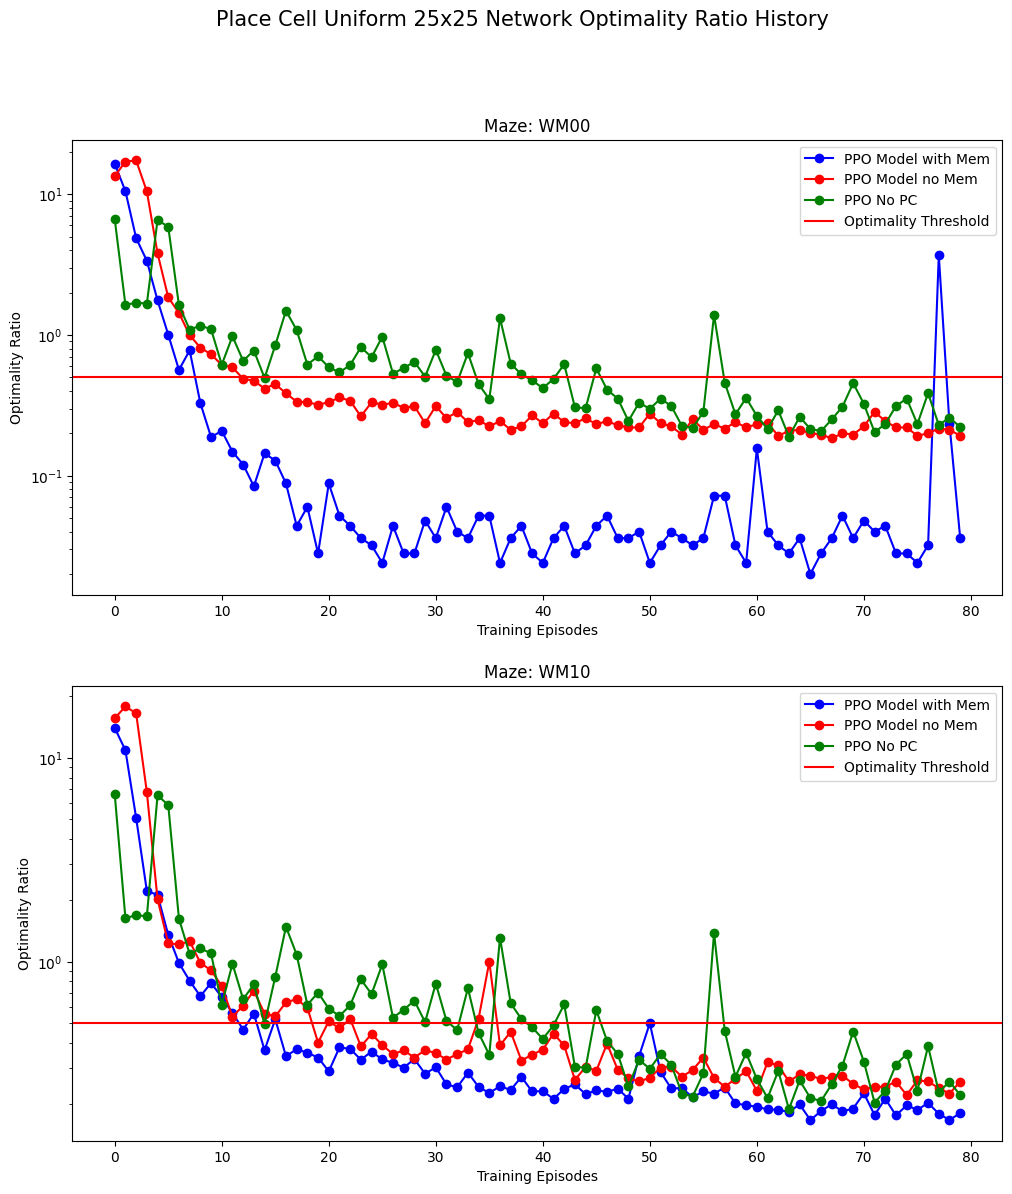

In [13]:
fig = plot_OR_history_comp_for_maze3(exp_data,exp_data_no_pc,exp_data_no_mem)
fig.savefig('Simulation/DataCache/UniformResults/uniform25_training_OR_three.png')

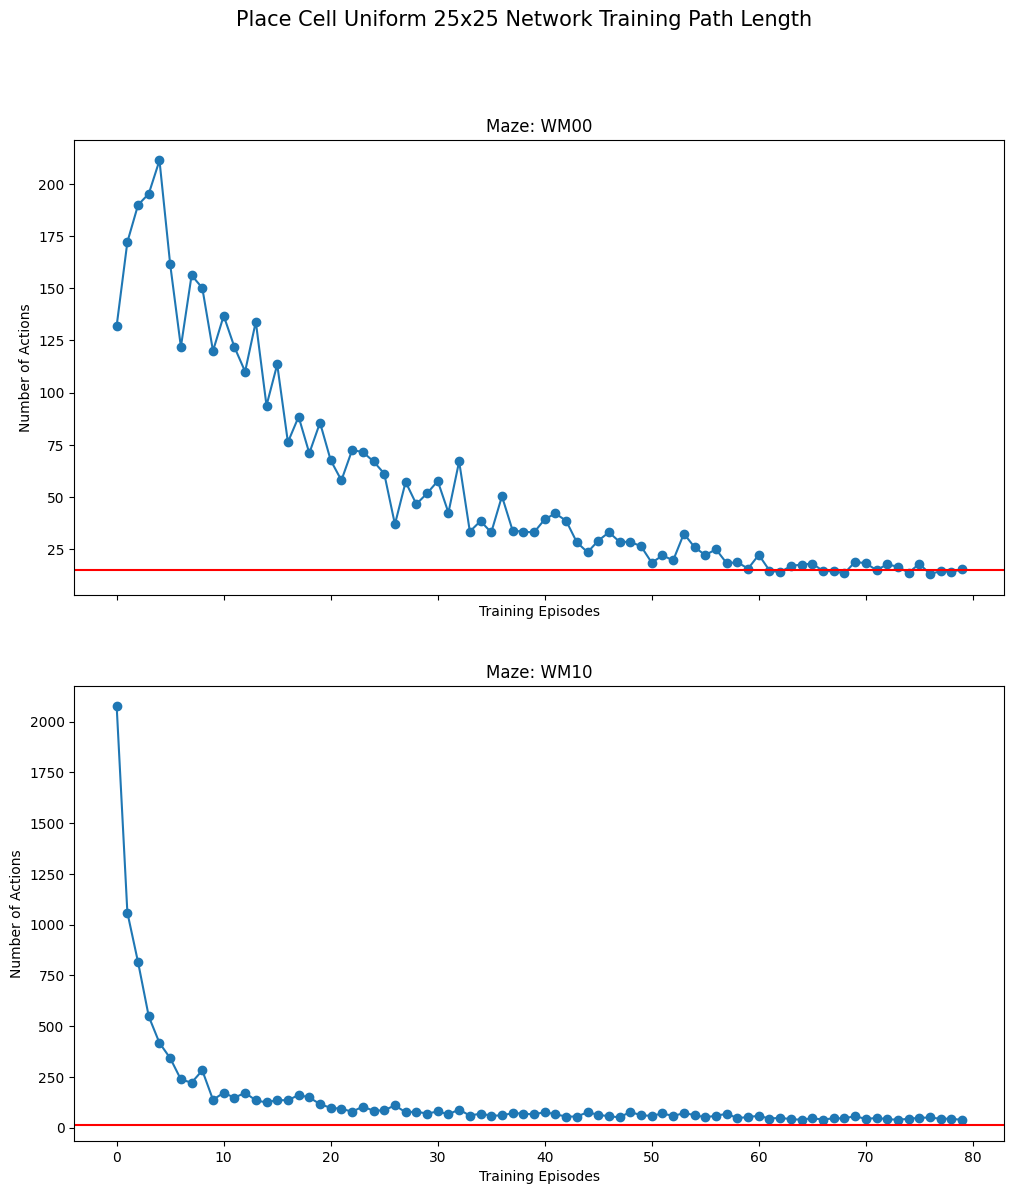

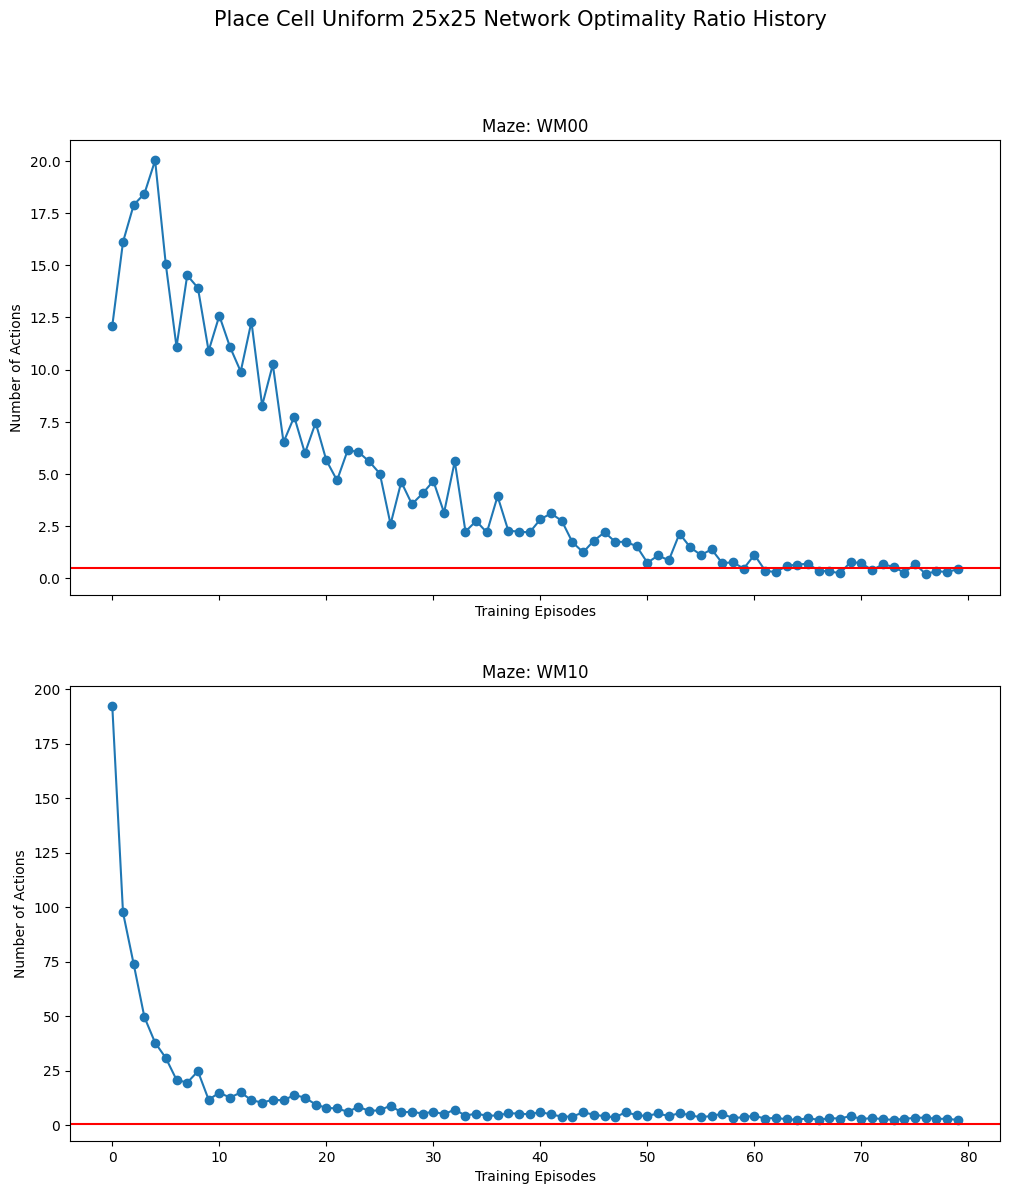

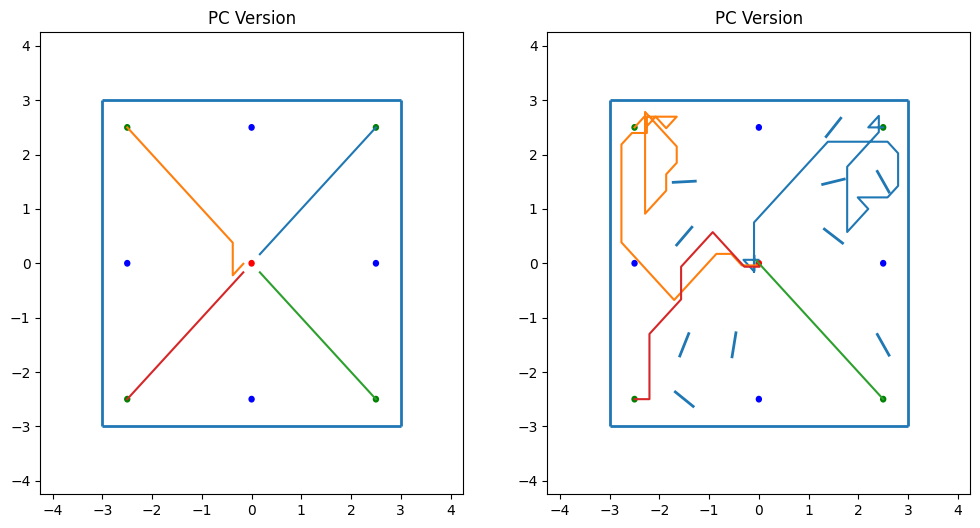

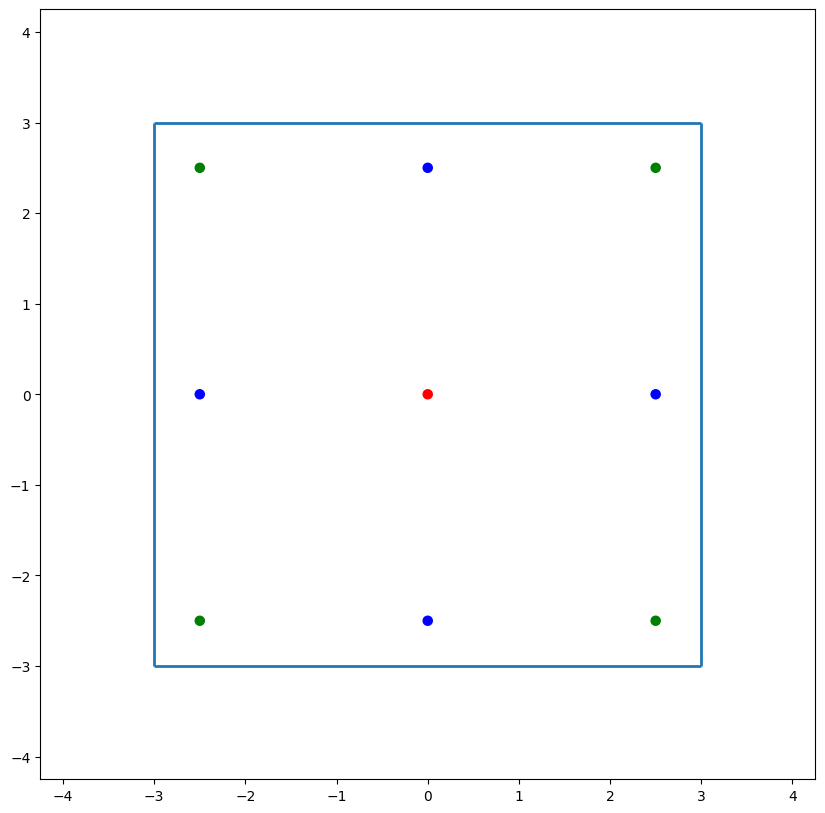

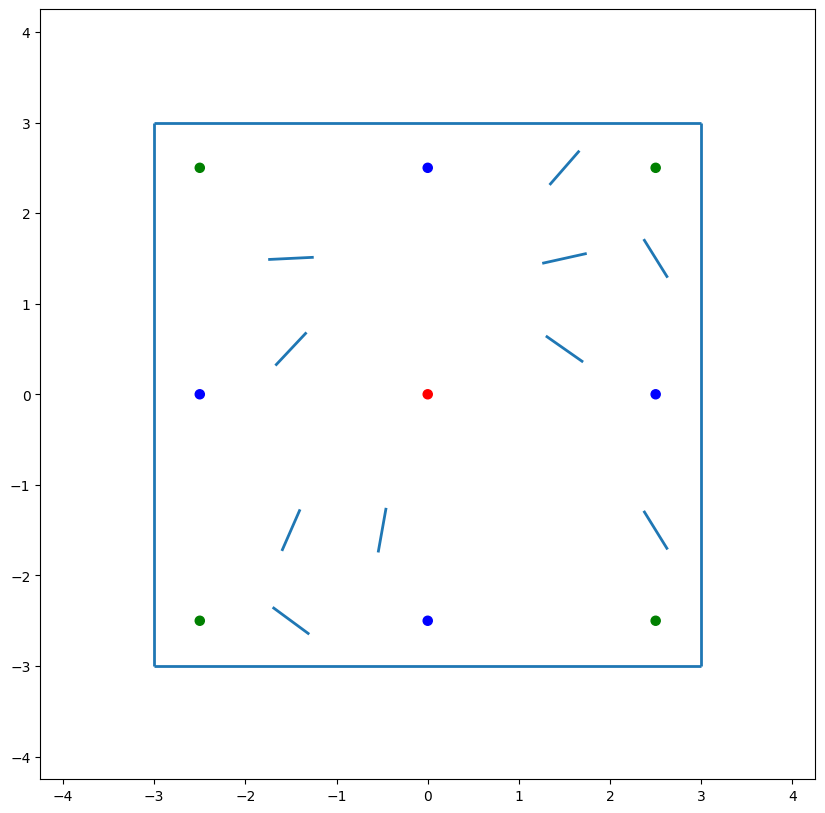

In [5]:
fig = plot_training_steps_for_maze(exp_data_MC)
fig.savefig('Simulation/DataCache/UniformResults/uniform25_training_length_MS.png')
fig = plot_OR_history_for_maze(exp_data_MC)
fig.savefig('Simulation/DataCache/UniformResults/uniform25_OR_history_MS.png')
fig = plot_last_paths(exp_data_MC)
fig.savefig('Simulation/DataCache/UniformResults/uniform25_training_paths_MS.png')


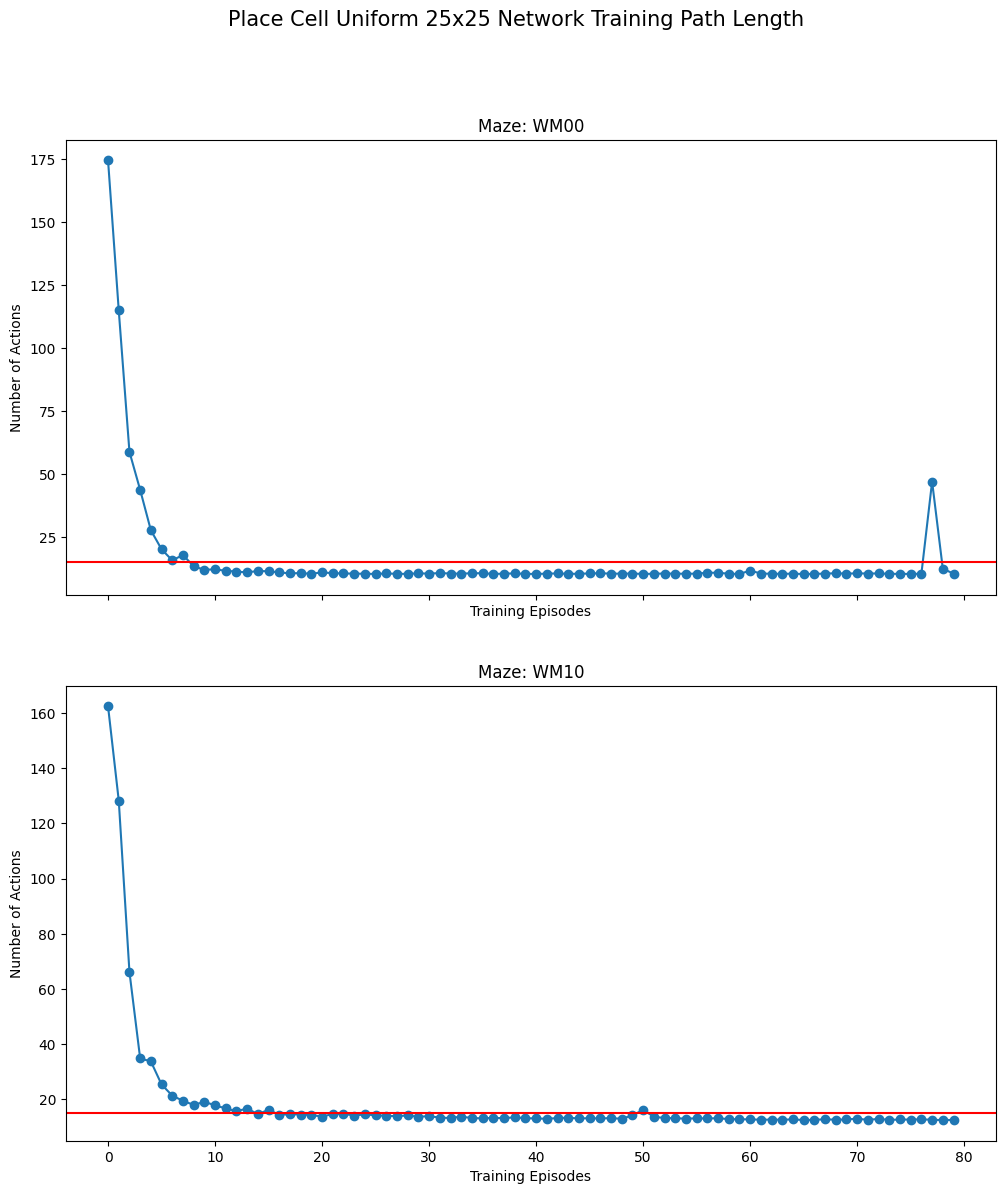

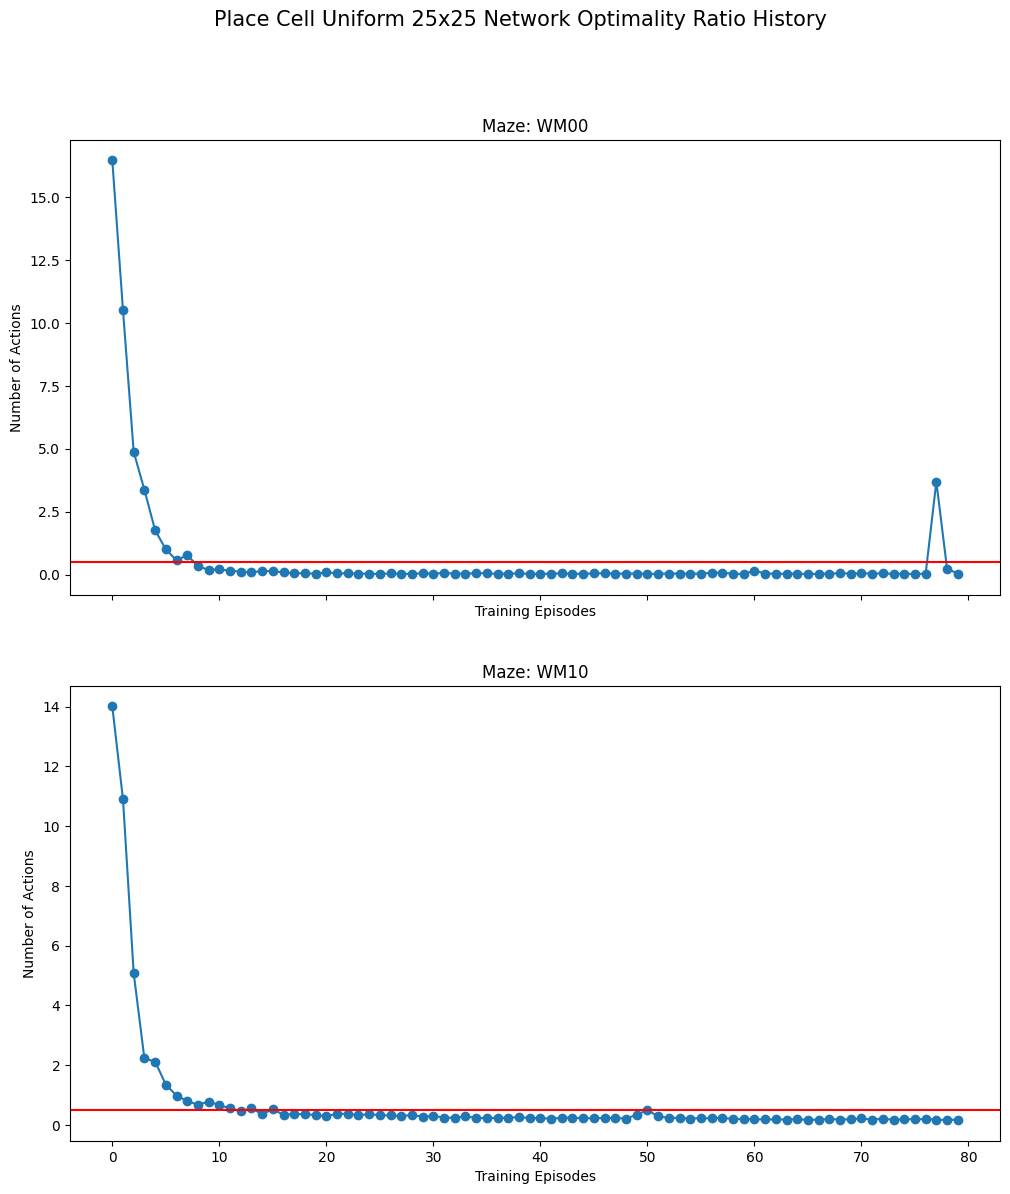

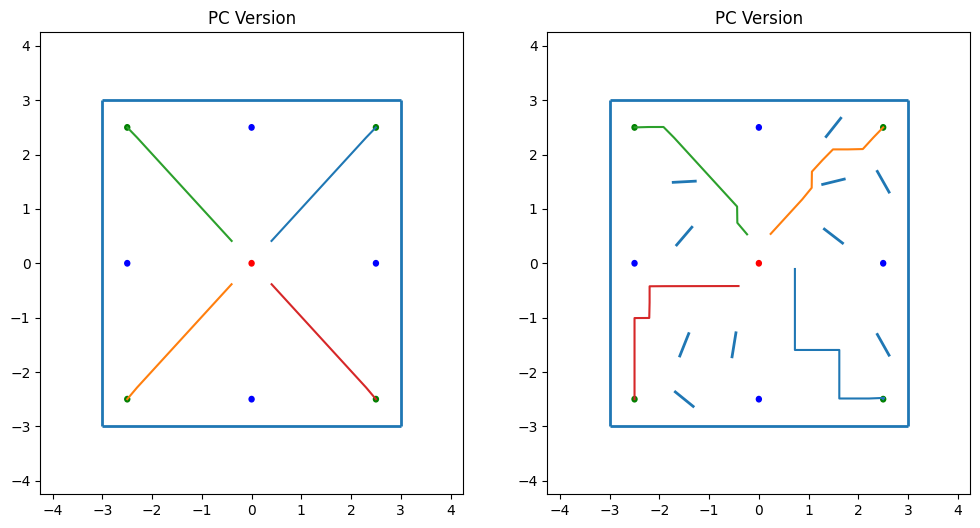

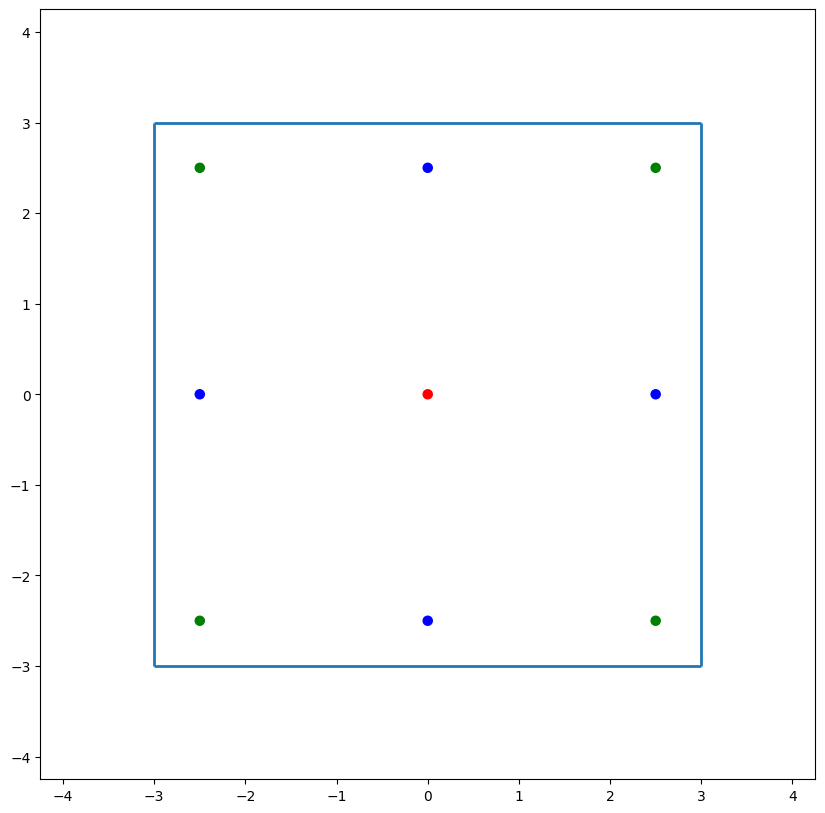

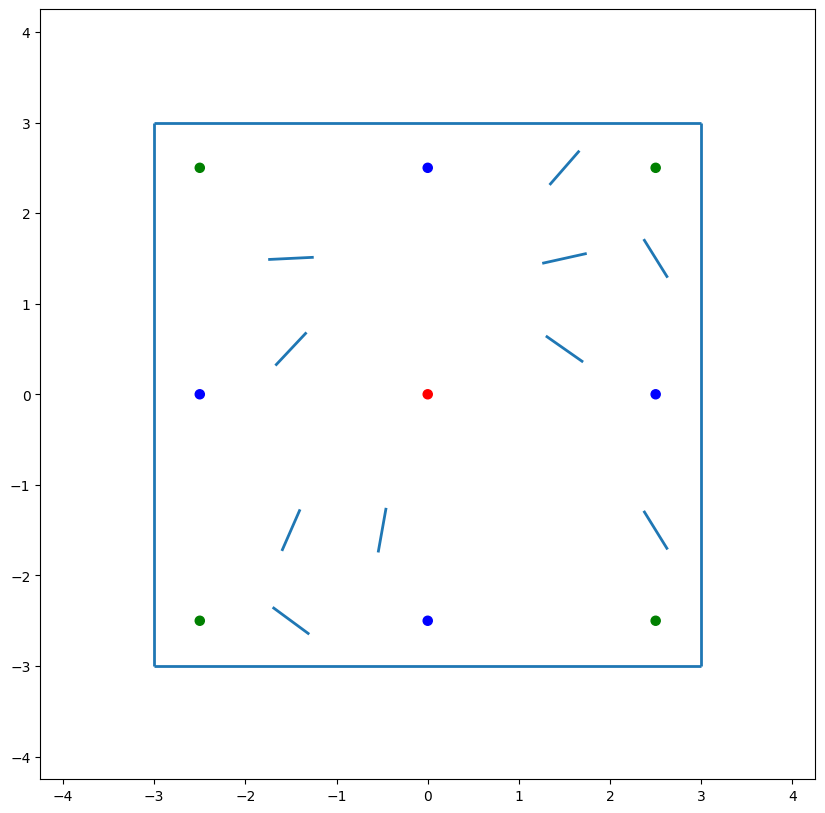

In [6]:
fig = plot_training_steps_for_maze(exp_data)
fig.savefig('Simulation/DataCache/UniformResults/uniform25_training_length.png')
fig = plot_OR_history_for_maze(exp_data)
fig.savefig('Simulation/DataCache/UniformResults/uniform25_OR_history.png')
fig = plot_last_paths(exp_data)
fig.savefig('Simulation/DataCache/UniformResults/uniform25_training_paths.png')